In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [5]:
start = "2005-01-01"
end = datetime.today()

In [ ]:
# Regime Detection

In [7]:
# Data extraction from Fred

# CPI - Inflation
cpi = web.DataReader("CPIAUCSL", "fred", start, end)

# 10Y Treasury Yield
yields = web.DataReader("DGS10", "fred", start, end)

# Industrial Production (Growth Proxy)
ip = web.DataReader("INDPRO", "fred", start, end)

In [17]:
# Data extraction from Yahoo Finance
vix = yf.download("^VIX", start=start, end=end, auto_adjust=True)["Close"]
vix.columns = ["VIX"]

[*********************100%***********************]  1 of 1 completed


In [23]:
# Example: assuming all are DataFrames with a Date index

data = cpi.join(ip, how="inner") \
                .join(yields, how="inner") \
                .join(vix, how="inner")

print(data.columns)

Index(['CPIAUCSL', 'INDPRO', 'DGS10', 'VIX'], dtype='object')


In [27]:
data.columns = ["Inflation", "Growth", "Yield", "VIX"]
print(data.columns)

Index(['Inflation', 'Growth', 'Yield', 'VIX'], dtype='object')


In [29]:
# Convert to monthly frequency

# CPI already monthly
cpi_monthly = cpi.resample("M").last()

# Industrial production
ip_monthly = ip.resample("M").last()

# Yields (daily → monthly avg)
yields_monthly = yields.resample("M").mean()

# VIX (daily → monthly avg)
vix_monthly = vix.resample("M").mean()

/var/folders/mp/r__mfhrd2310ndf7csqx3kyh0000gn/T/ipykernel_79677/3768003497.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  cpi_monthly = cpi.resample("M").last()
/var/folders/mp/r__mfhrd2310ndf7csqx3kyh0000gn/T/ipykernel_79677/3768003497.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ip_monthly = ip.resample("M").last()
/var/folders/mp/r__mfhrd2310ndf7csqx3kyh0000gn/T/ipykernel_79677/3768003497.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  yields_monthly = yields.resample("M").mean()
/var/folders/mp/r__mfhrd2310ndf7csqx3kyh0000gn/T/ipykernel_79677/3768003497.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vix_monthly = vix.resample("M").mean()


In [31]:
# Computing derived variables

cpi_yoy = cpi_monthly.pct_change(12) * 100
cpi_yoy.columns = ["Inflation"]

ip_yoy = ip_monthly.pct_change(12) * 100
ip_yoy.columns = ["Growth"]

yields_monthly.columns = ["Yield"]

/var/folders/mp/r__mfhrd2310ndf7csqx3kyh0000gn/T/ipykernel_79677/1994257297.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi_yoy = cpi_monthly.pct_change(12) * 100


In [33]:
# Merge everything
data = pd.concat([
    cpi_yoy,
    ip_yoy,
    yields_monthly,
    vix_monthly
], axis=1)

data = data.dropna()

In [43]:
# Standardize the data
data_z = (data - data.mean()) / data.std()

In [45]:
# Regime Classification
def classify_regime(row):
    
    growth = row["Growth"]
    inflation = row["Inflation"]
    yield_ = row["Yield"]
    vol = row["VIX"]
    
    # Expansion
    if growth > 0 and inflation < 0 and vol < 0:
        return "Expansion"
    
    # Inflationary Tightening
    elif inflation > 0 and yield_ > 0:
        return "Inflationary Tightening"
    
    # Stagflation / Slowdown
    elif growth < 0 and inflation > 0:
        return "Stagflation"
    
    # Crisis / Risk-Off
    elif vol > 1 and yield_ < 0:
        return "Crisis"
    
    else:
        return "Neutral"

In [49]:
# Apply classification

data_z["Regime"] = data_z.apply(classify_regime, axis=1)
print(data_z.head())

            Inflation    Growth     Yield       VIX                   Regime
2006-01-31   0.766137  0.451624  1.330677 -0.900239  Inflationary Tightening
2006-02-28   0.566999  0.300020  1.467022 -0.847465  Inflationary Tightening
2006-03-31   0.451696  0.380114  1.605166 -0.941736  Inflationary Tightening
2006-04-30   0.554221  0.399755  1.842839 -0.923121  Inflationary Tightening
2006-05-31   0.744411  0.385375  1.949344 -0.606857  Inflationary Tightening


In [51]:
data_z["Regime"].value_counts()

Regime
Neutral                    90
Inflationary Tightening    72
Expansion                  65
Crisis                     14
Stagflation                 2
Name: count, dtype: int64

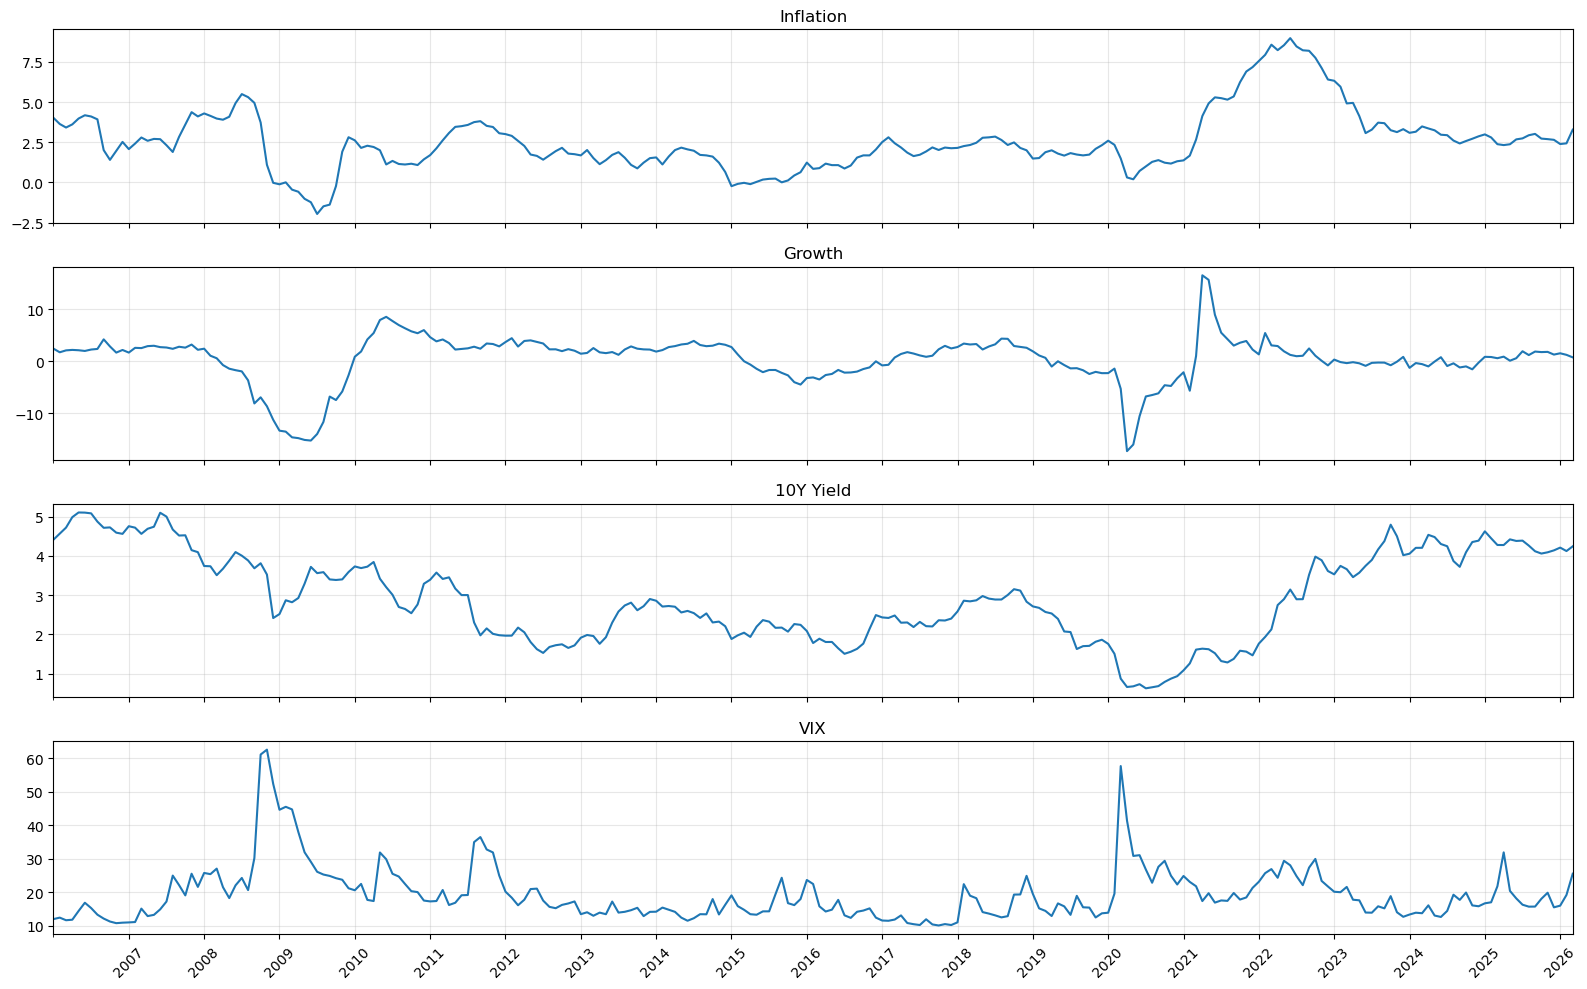

In [71]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure datetime index
data.index = pd.to_datetime(data.index)

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

data["Inflation"].plot(ax=axes[0])
axes[0].set_title("Inflation")

data["Growth"].plot(ax=axes[1])
axes[1].set_title("Growth")

data["Yield"].plot(ax=axes[2])
axes[2].set_title("10Y Yield")

data["VIX"].plot(ax=axes[3])
axes[3].set_title("VIX")

# ---- FORCE YEARLY TICKS ----
years = pd.date_range(start=data.index.min(), end=data.index.max(), freq='YS')

axes[-1].set_xticks(years)
axes[-1].set_xticklabels([d.year for d in years], rotation=45)

# ---- FORCE FULL RANGE ----
axes[-1].set_xlim(data.index.min(), data.index.max())

# Grid
for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
# Asset Behavior

In [143]:
# Cross-Asset

macro_tickers = {
    "SPY": "Equities",
    "GLD": "Gold",
    "EEM": "Emerging Markets",
    "TLT": "Bonds",
    "USO": "Oil",
    "^VIX": "Volatility"
}

# All Sectors in the US
sector_tickers = {
    "XLK": "Technology",
    "XLF": "Financials",
    "XLV": "Healthcare",
    "XLE": "Energy",
    "XLY": "Consumer Discretionary",
    "XLP": "Staples",
    "XLI": "Industrials",
    "XLB": "Materials",
    "XLU": "Utilities",
    "XLRE": "Real Estate",
    "XLC": "Communication Services"
}

start = "2021-01-01"
end = "2026-04-28"
event_date = "2026-02-28"

In [149]:
# Download the Data
macro = yf.download(list(macro_tickers.keys()), start=start, end=end)["Close"]
sectors = yf.download(list(sector_tickers.keys()), start=start, end=end)["Close"]

macro.columns = [macro_tickers[col] for col in macro.columns]
sectors.columns = [sector_tickers[col] for col in sectors.columns]

macro = macro.dropna()
sectors = sectors.dropna()

macro.info()
sectors.info()

[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  11 of 11 completed


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1334 entries, 2021-01-04 to 2026-04-27
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Emerging Markets  1334 non-null   float64
 1   Gold              1334 non-null   float64
 2   Equities          1334 non-null   float64
 3   Bonds             1334 non-null   float64
 4   Oil               1334 non-null   float64
 5   Volatility        1334 non-null   float64
dtypes: float64(6)
memory usage: 73.0 KB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1334 entries, 2021-01-04 to 2026-04-27
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Materials      1334 non-null   float64
 1   Comm Services  1334 non-null   float64
 2   Energy         1334 non-null   float64
 3   Financials     1334 non-null   float64
 4   Industrials    1334 non-null   float64
 5   Technology     1334 n

In [151]:
# Normalize the data - base = 100

macro_norm = macro/macro.iloc[0]*100
sectors_norm = sectors/sectors.iloc[0]*100

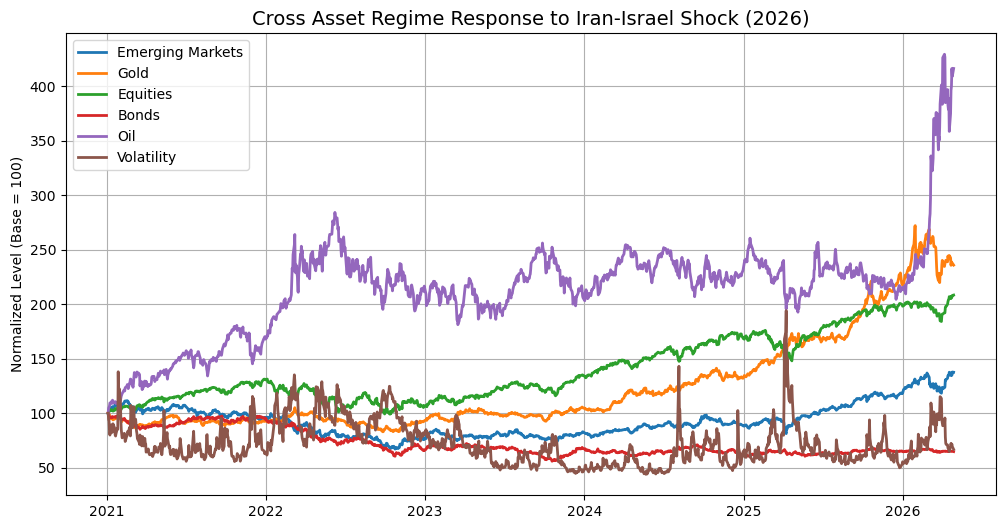

In [153]:
# Cross Asset Regime Validation
plt.figure(figsize=(12,6))

for col in macro_norm.columns:
    plt.plot(macro_norm.index, macro_norm[col], linewidth=2)

plt.title("Cross Asset Regime Response to Iran-Israel Shock (2026)", fontsize=14)
plt.ylabel("Normalized Level (Base = 100)")
plt.legend(macro_norm.columns, loc="upper left")
plt.grid(True)

plt.show()

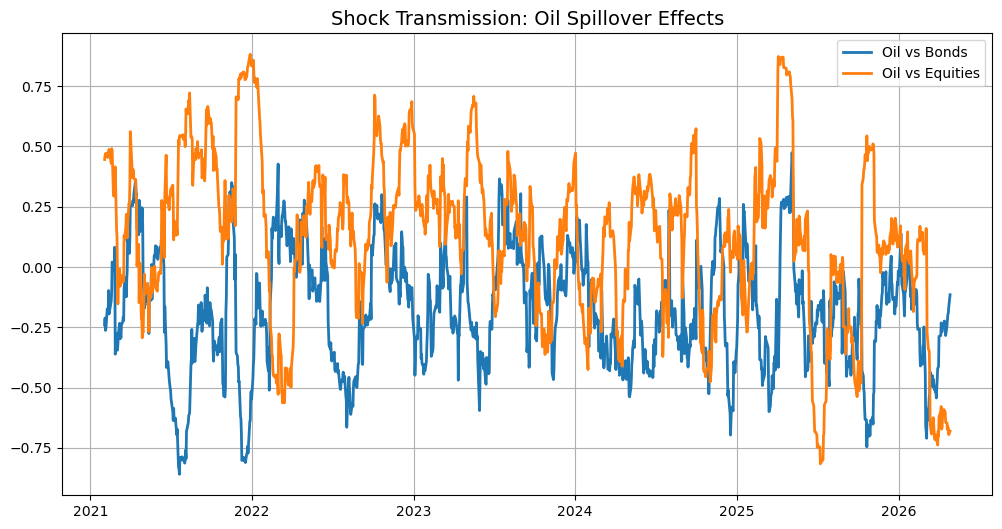

In [159]:
# Shock Transmission
# Oil -> Bonds vs. Equities

returns = macro.pct_change().dropna()
oil_bonds = returns["Oil"].rolling(20).corr(returns["Bonds"])
oil_equities = returns["Oil"].rolling(20).corr(returns["Equities"])

plt.figure(figsize=(12,6))

plt.plot(oil_bonds, linewidth=2, label="Oil vs Bonds")
plt.plot(oil_equities, linewidth=2, label="Oil vs Equities")

plt.title("Shock Transmission: Oil Spillover Effects", fontsize=14)
plt.legend()
plt.grid(True)

plt.show()

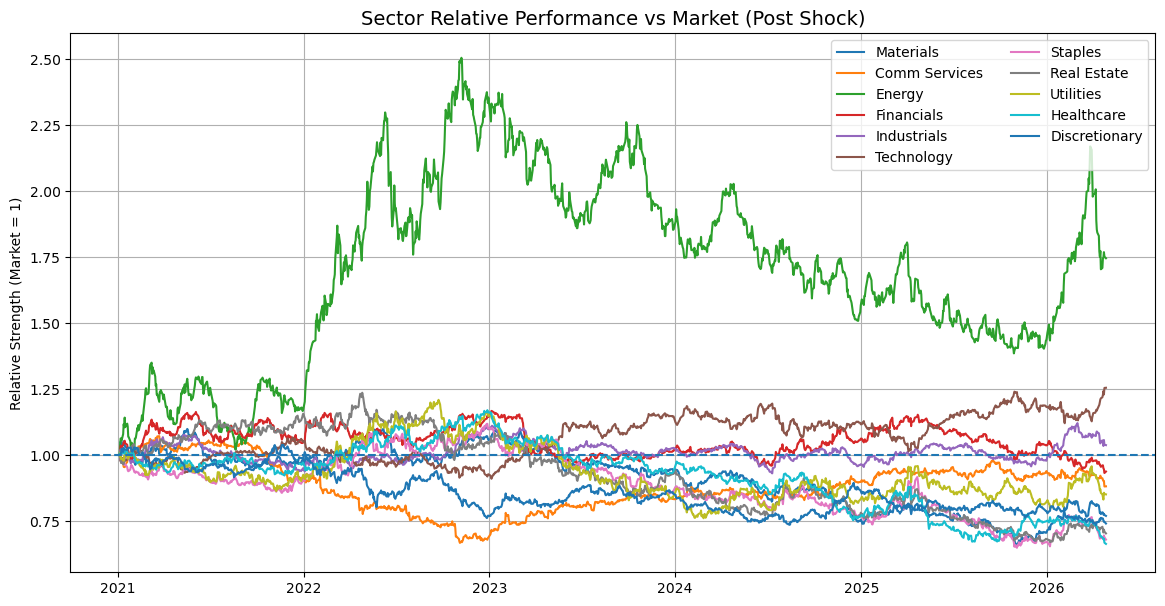

In [169]:
# Sector Divergence

sector_vs_market = sectors_norm.div(macro_norm["Equities"], axis=0)

plt.figure(figsize=(14,7))

for col in sector_vs_market.columns:
    plt.plot(sector_vs_market.index, sector_vs_market[col], label=col)
plt.axhline(1, linestyle="--")

plt.title("Sector Relative Performance vs Market (Post Shock)", fontsize =14)
plt.ylabel("Relative Strength (Market = 1)")
plt.legend(ncol=2)
plt.grid(True)
plt.show()

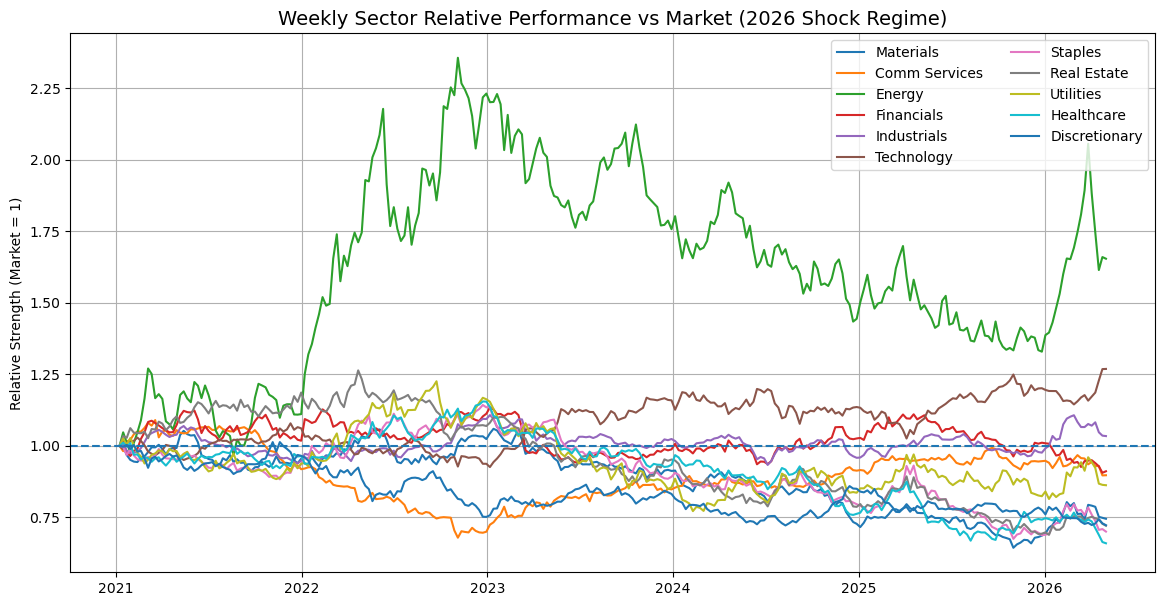

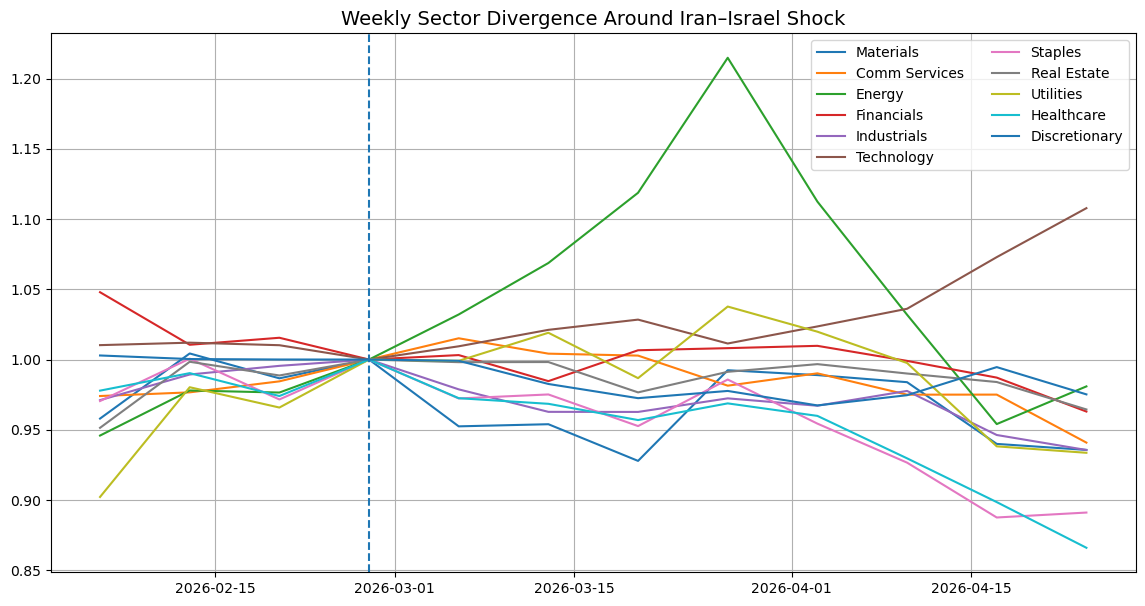

In [181]:
# Looking at the above chart closely in 2026 - weekly

# resampling macros and sectors
macro_w = macro.resample("W-FRI").last()
sectors_w = sectors.resample("W-FRI").last()

# ------
# normalize weekly
macro_w_norm = macro_w / macro_w.iloc[0] * 100
sector_w_norm = sectors_w / sectors_w.iloc[0] * 100

# ----
# Sector vs market (weekly alpha)
sector_vs_market_w = sector_w_norm.div(macro_w_norm["Equities"], axis=0)

# ---------
# Weekly Chart
plt.figure(figsize=(14,7))

for col in sector_vs_market_w.columns:
    plt.plot(sector_vs_market_w.index, sector_vs_market_w[col], label=col)

plt.axhline(1, linestyle="--")

plt.title("Weekly Sector Relative Performance vs Market (2026 Shock Regime)", fontsize=14)
plt.ylabel("Relative Strength (Market = 1)")
plt.legend(ncol=2)
plt.grid(True)

plt.show()

# -----
# Chart 2
event_date = pd.to_datetime("2026-02-28")

closest = sector_vs_market_w.index.get_indexer([event_date], method="nearest")[0]
base_date = sector_vs_market_w.index[closest]

weekly_event = sector_vs_market_w.loc[
    base_date - pd.Timedelta(weeks=3):
    base_date + pd.Timedelta(weeks=8)
]

weekly_event_rebased = weekly_event / weekly_event.loc[base_date]

plt.figure(figsize=(14,7))

for col in weekly_event_rebased.columns:
    plt.plot(weekly_event_rebased.index, weekly_event_rebased[col], label=col)

plt.axvline(base_date, linestyle="--")

plt.title("Weekly Sector Divergence Around Iran–Israel Shock", fontsize=14)
plt.legend(ncol=2)
plt.grid(True)

plt.show()


In [183]:
# Event Study
event_date = pd.to_datetime("2026-02-28")

# find closest index in dataframe
closest_date = sector_vs_market.index.get_indexer([event_date], method="nearest")[0]
base_date = sector_vs_market.index[closest_date]

event_data = sector_vs_market.loc[
    base_date - pd.Timedelta(days=15):
    base_date + pd.Timedelta(days=60)
]

event_rebased = event_data / event_data.loc[base_date]

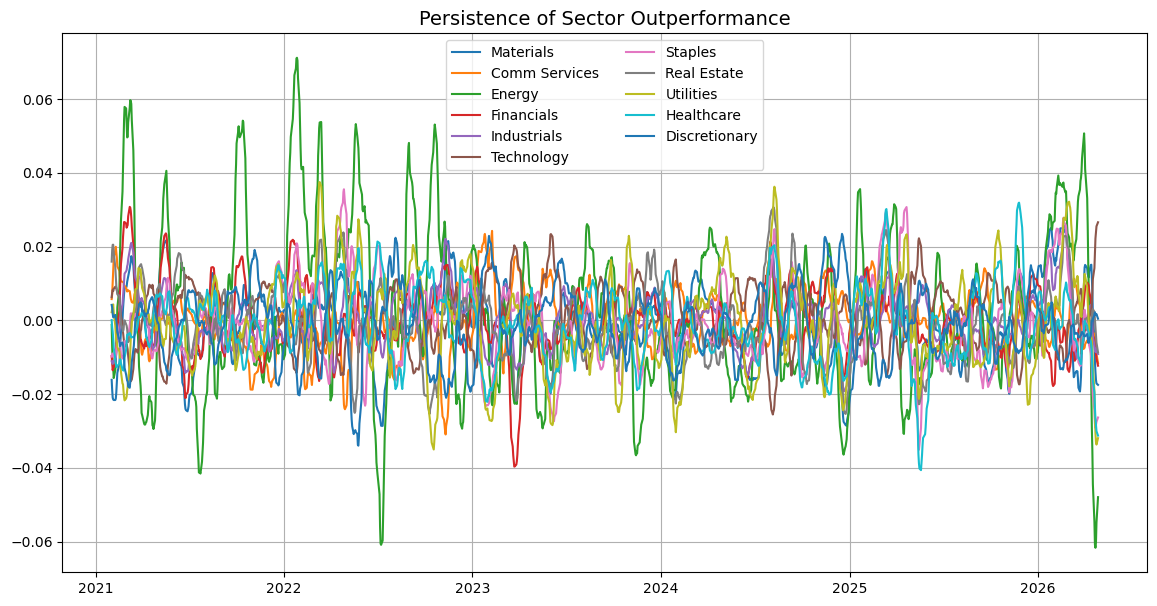

In [185]:
rolling_strength = sector_vs_market.pct_change(5).rolling(15).mean()

plt.figure(figsize=(14,7))

for col in rolling_strength.columns:
    plt.plot(rolling_strength.index, rolling_strength[col], label=col)

plt.title("Persistence of Sector Outperformance", fontsize=14)
plt.legend(ncol=2)
plt.grid(True)

plt.show()

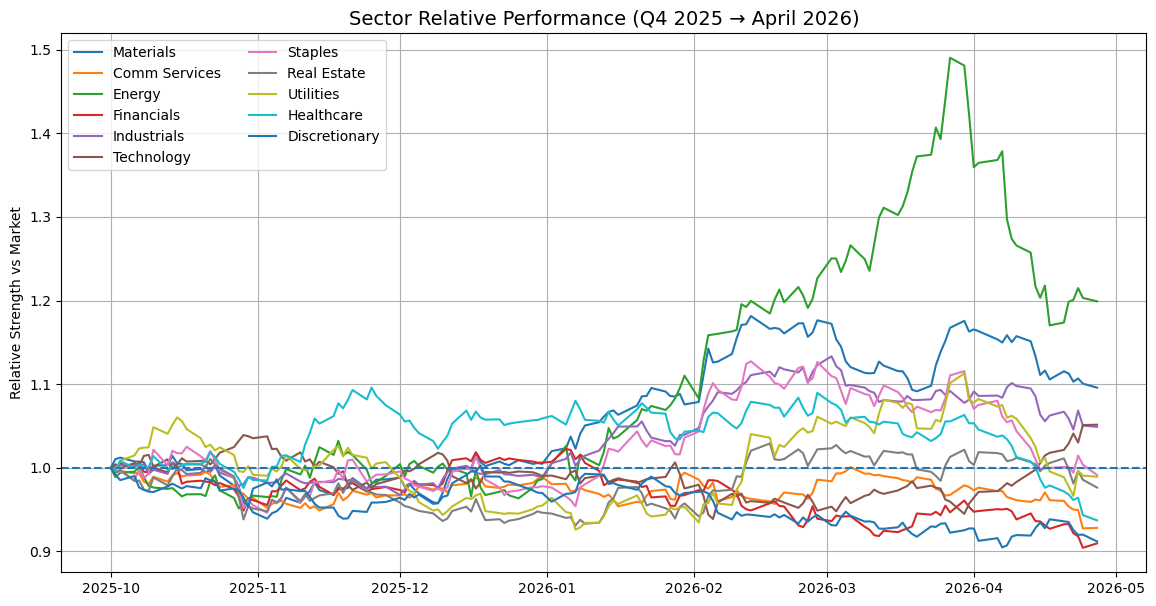

In [187]:
# Lets zoom in on the above chart

start_zoom = "2025-10-01"
end_zoom = "2026-04-28"
event_date1 = pd.to_datetime("2026-02-28")

# ----- 
# Filter data
macro_z = macro.loc[start_zoom:end_zoom]
sectors_z = sectors.loc[start_zoom:end_zoom]

# -----
# Normalize within the zoom window
macro_z_norm = macro_z / macro_z.iloc[0] * 100
sectors_z_norm = sectors_z / sectors_z.iloc[0] * 100

# -----
# Sector Vs Market
sector_vs_market_z = sectors_z_norm.div(macro_z_norm["Equities"], axis=0)

# -----
# Zoomed chart
plt.figure(figsize=(14,7))

for col in sector_vs_market_z.columns:
    plt.plot(sector_vs_market_z.index, sector_vs_market_z[col], label=col)

plt.axhline(1, linestyle="--")

plt.title("Sector Relative Performance (Q4 2025 → April 2026)", fontsize=14)
plt.ylabel("Relative Strength vs Market")
plt.legend(ncol=2)
plt.grid(True)

plt.show()

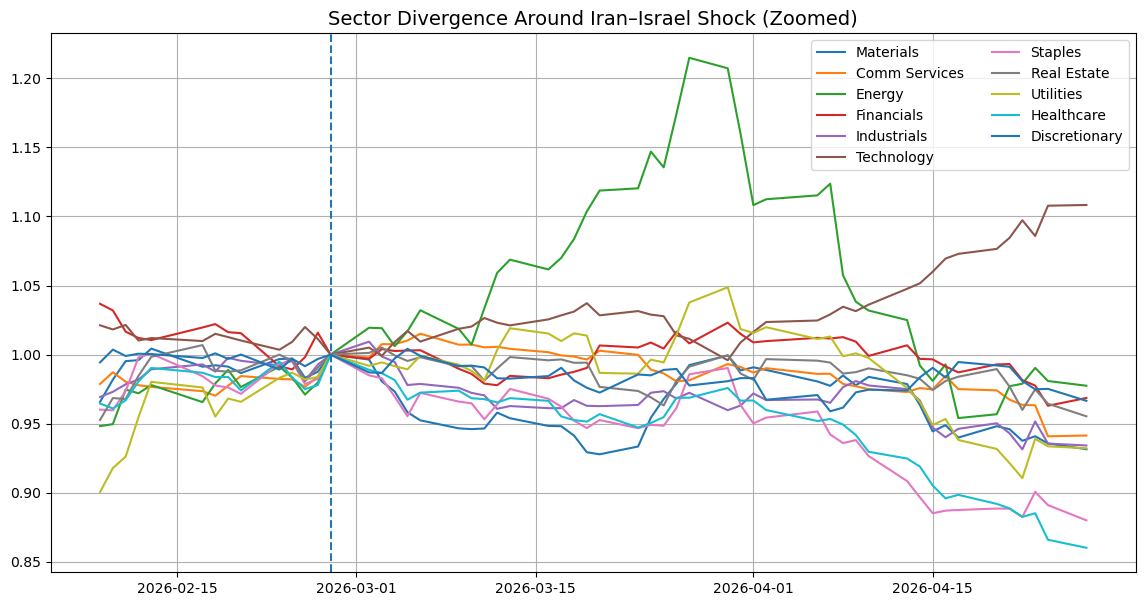

In [191]:
# Event Centered Zoom
closest_idx = sector_vs_market_z.index.get_indexer([event_date], method="nearest")[0]
base_date = sector_vs_market_z.index[closest_idx]

event_window = sector_vs_market_z.loc[
    base_date - pd.Timedelta(days=20):
    base_date + pd.Timedelta(days=60)
]

event_rebased = event_window / event_window.loc[base_date]

# Chart
plt.figure(figsize=(14,7))

for col in event_rebased.columns:
    plt.plot(event_rebased.index, event_rebased[col], label=col)

plt.axvline(base_date, linestyle="--")

plt.title("Sector Divergence Around Iran–Israel Shock (Zoomed)", fontsize=14)
plt.legend(ncol=2)
plt.grid(True)

plt.show()

In [321]:
# Analyzing how the war affected the global economies using their stock market indicator

eq_tickers = {
    "S&P 500" : "^GSPC",
    "Euro Stoxx 50" : "^STOXX50E",
    "Nikkei 225" : "^N225",
    "Nifty 50" : "^NSEI",
    "KOSPI" : "^KS11",
    "CSI 300" : "000300.SS",
    "Hang Seng" : "^HSI",
}

# Download the Data
eq_start = "2025-12-01"
eq_end = "2026-04-30"

eq_data = yf.download(list(eq_tickers.values()), start=eq_start, end=eq_end)["Close"]

[*********************100%***********************]  7 of 7 completed


In [323]:
eq_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 2025-12-01 to 2026-04-29
Freq: B
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   000300.SS  99 non-null     float64
 1   ^GSPC      103 non-null    float64
 2   ^HSI       99 non-null     float64
 3   ^KS11      101 non-null    float64
 4   ^N225      100 non-null    float64
 5   ^NSEI      100 non-null    float64
 6   ^STOXX50E  100 non-null    float64
dtypes: float64(7)
memory usage: 6.8 KB


In [325]:
eq_data.columns = eq_tickers.keys()

In [327]:
eq_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 2025-12-01 to 2026-04-29
Freq: B
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   S&P 500        99 non-null     float64
 1   Euro Stoxx 50  103 non-null    float64
 2   Nikkei 225     99 non-null     float64
 3   Nifty 50       101 non-null    float64
 4   KOSPI          100 non-null    float64
 5   CSI 300        100 non-null    float64
 6   Hang Seng      100 non-null    float64
dtypes: float64(7)
memory usage: 6.8 KB


In [329]:
eq_data.describe()

,S&P 500,Euro Stoxx 50,Nikkei 225,Nifty 50,KOSPI,CSI 300,Hang Seng
count,99.000000,103.000000,99.000000,101.000000,100.000000,100.000000,100.000000
mean,4651.949904,6850.647475,26102.448430,5191.579206,54048.369414,24993.855078,5859.684697
std,94.072665,162.292221,679.707750,759.321090,3032.539581,1102.300934,160.923578
min,4418.000000,6343.720215,24382.470703,3920.370117,49001.500000,22331.400391,5501.279785
25%,4583.895020,6797.629883,25670.314453,4552.370117,51753.472656,24152.962891,5730.929932
50%,4660.410156,6878.490234,25978.070312,5288.080078,53694.640625,25462.724609,5893.405029
75%,4724.004883,6940.739990,26599.400391,5763.220215,56518.699219,25869.687988,5985.655029
max,4810.350098,7173.910156,27968.089844,6690.899902,60537.359375,26328.550781,6173.319824


In [331]:
eq_data.isnull().sum()

S&P 500          9
Euro Stoxx 50    5
Nikkei 225       9
Nifty 50         7
KOSPI            8
CSI 300          8
Hang Seng        8
dtype: int64

In [333]:
eq_data = eq_data.fillna(method = "ffill")
eq_data.isnull().sum()

/var/folders/mp/r__mfhrd2310ndf7csqx3kyh0000gn/T/ipykernel_79677/987945641.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  eq_data = eq_data.fillna(method = "ffill")


S&P 500          0
Euro Stoxx 50    0
Nikkei 225       0
Nifty 50         0
KOSPI            0
CSI 300          0
Hang Seng        0
dtype: int64

In [335]:
eq_data.head()

,S&P 500,Euro Stoxx 50,Nikkei 225,Nifty 50,KOSPI,CSI 300,Hang Seng
Date,,,,,,,
2025-12-01,4576.490234,6812.629883,26033.259766,3920.370117,49303.281250,26175.750000,5667.479980
2025-12-02,4554.330078,6829.370117,26095.050781,3994.929932,49303.449219,26032.199219,5686.169922
2025-12-03,4531.049805,6849.720215,25760.730469,4036.300049,49864.679688,25986.000000,5694.560059
2025-12-04,4546.569824,6857.120117,25935.900391,4028.510010,51028.421875,26033.750000,5718.080078
2025-12-05,4584.540039,6870.399902,26085.080078,4100.049805,50491.871094,26186.449219,5723.930176


In [337]:
eq_weeklydata = eq_data.resample("W-Fri").last()
eq_weeklydata.head()

,S&P 500,Euro Stoxx 50,Nikkei 225,Nifty 50,KOSPI,CSI 300,Hang Seng
Date,,,,,,,
2025-12-05,4584.540039,6870.399902,26085.080078,4100.049805,50491.871094,26186.449219,5723.930176
2025-12-12,4580.950195,6827.410156,25976.789062,4167.160156,50836.550781,26046.949219,5720.709961
2025-12-19,4568.180176,6834.500000,25690.529297,4020.550049,49507.210938,25966.400391,5760.350098
2025-12-26,4657.240234,6929.939941,25818.929688,4129.680176,50750.390625,26042.300781,5749.279785
2026-01-02,4629.939941,6858.470215,26338.470703,4309.629883,50339.480469,26328.550781,5796.220215


In [339]:
# Normalizing the data to base = 100
eq_normalized = eq_weeklydata / eq_weeklydata.iloc[0] * 100

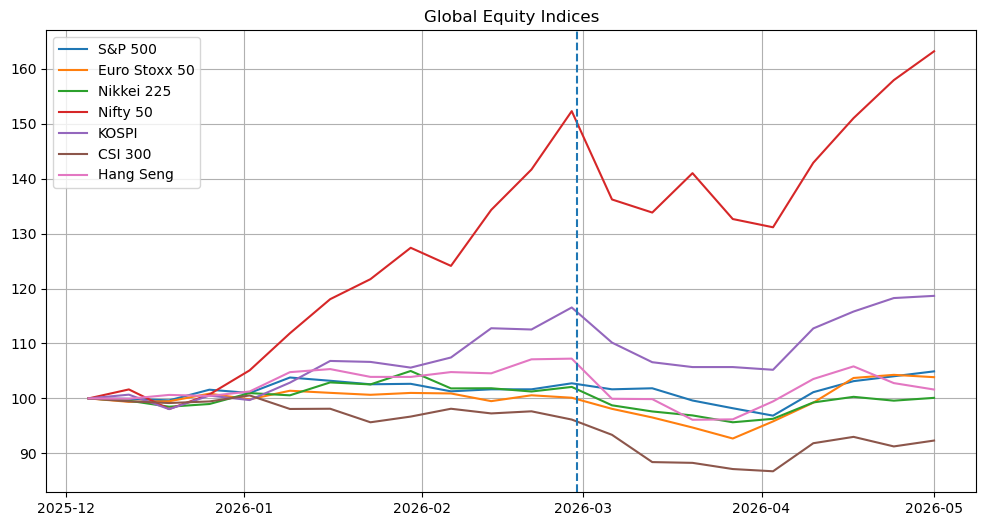

In [341]:
plt.figure(figsize=(12,6))

for col in eq_normalized.columns:
    plt.plot(eq_normalized.index, eq_normalized[col], label=col)

plt.axvline(pd.to_datetime("2026-02-28"), linestyle="--")
plt.title("Global Equity Indices")
plt.legend()
plt.grid(True)
plt.show()

In [361]:
# Nifty 50 spiked the most in the data. Let's find out if there is any data issue or was the spike due to some different factors.

<Axes: xlabel='Date'>

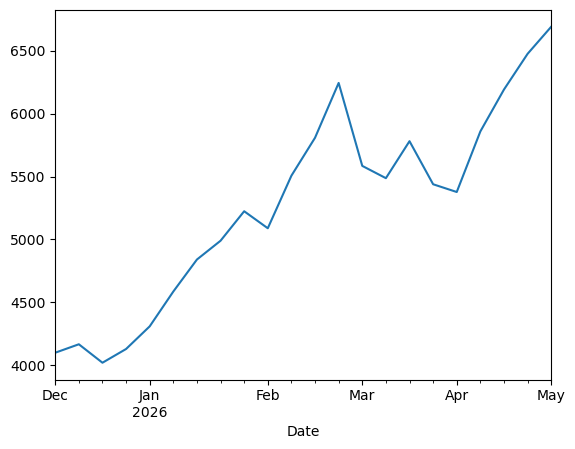

In [345]:
eq_weeklydata["Nifty 50"].plot()

<Axes: xlabel='Date'>

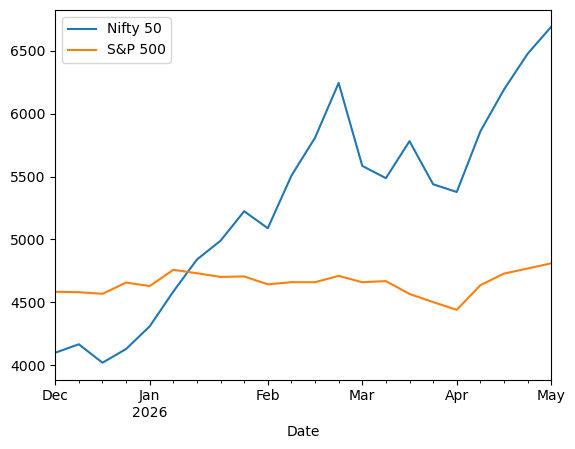

In [347]:
eq_weeklydata[["Nifty 50", "S&P 500"]].plot()

<Axes: xlabel='Date'>

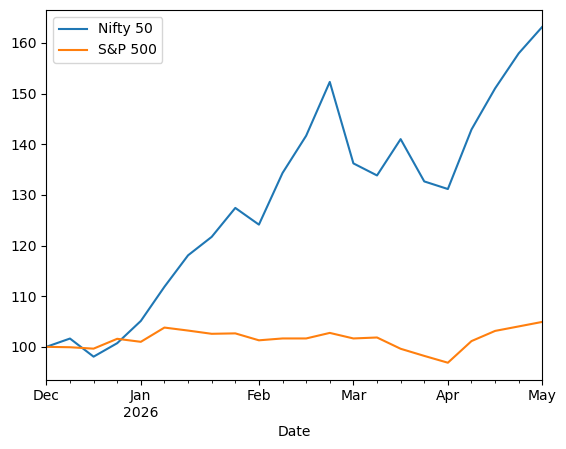

In [349]:
eq_normalized[["Nifty 50", "S&P 500"]].plot()

In [351]:
eq_returns = (eq_weeklydata.iloc[-1] / eq_weeklydata.iloc[0] - 1) * 100
print(eq_returns.sort_values(ascending=False))

Nifty 50         63.190698
KOSPI            18.667539
S&P 500           4.925468
Euro Stoxx 50     3.865136
Hang Seng         1.616893
Nikkei 225        0.102586
CSI 300          -7.671139
dtype: float64


[*********************100%***********************]  1 of 1 completed


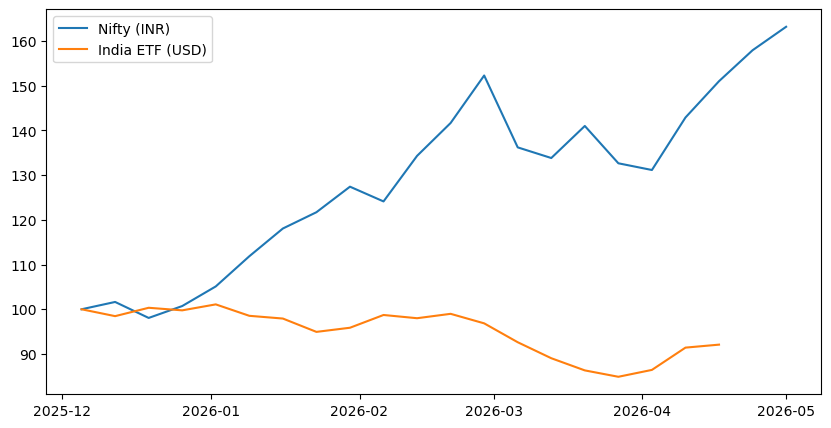

In [357]:
india_usd = yf.download("INDA", start="2025-12-01", end="2026-04-15")["Close"]

india_usd = india_usd.resample('W-FRI').last().ffill()
india_usd_norm = india_usd / india_usd.iloc[0] * 100

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(eq_normalized["Nifty 50"], label="Nifty (INR)")
plt.plot(india_usd_norm, label="India ETF (USD)")
plt.legend()
plt.show()

In [359]:
eq_weeklydata["Nifty 50"].pct_change().sort_values(ascending=False).head(5)

Date
2026-04-10    0.089556
2026-02-13    0.082110
2026-02-27    0.074993
2026-01-09    0.064203
2026-04-17    0.056845
Name: Nifty 50, dtype: float64

In [ ]:
## Can conclude that the spike in India could be related partly to currency driven and not equity driven.